# Previsão de Churn de Clientes

## 1. Introdução e Contexto de Negócio
O termo **Churn** refere-se à perda de clientes em um determinado serviço ou produto — por exemplo, quando um cliente cancela sua assinatura de internet, dizemos que ocorreu um *churn*. 

Com essa definição estabelecida, o problema de negócio deste projeto consiste em desenvolver um modelo de Machine Learning capaz de identificar antecipadamente os clientes com alta probabilidade de cancelamento, permitindo que a empresa tome decisões estratégicas de retenção de forma preventiva.

## 2. Importando Bibliotecas e Dados

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [119]:
tabela = pd.read_csv("Churn_Modelling.csv")

## 3. Entendendo a Tabela

In [120]:
tabela.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [121]:
# Transformando os nomes de colunas do alemão para o português
colunas = {
    'RowNumber': 'numero_linha', 
    'CustomerId': 'id_cliente', 
    'Surname': 'sobrenome', 
    'CreditScore': 'pontuacao_credito', 
    'Geography': 'pais_residencia', 
    'Gender': 'genero', 
    'Age': 'idade', 
    'Tenure': 'tempo_cliente_anos', 
    'Balance': 'saldo_conta', 
    'NumOfProducts': 'qtd_produtos', 
    'HasCrCard': 'possui_cartao_credito', 
    'IsActiveMember': 'membro_ativo', 
    'EstimatedSalary': 'salario_estimado', 
    'Exited': 'churn'  
}
tabela = tabela.rename(columns = colunas)

In [122]:
tabela.info() # Todos os tipos de dados estão corretos para o intuito do projeto

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   numero_linha           10000 non-null  int64  
 1   id_cliente             10000 non-null  int64  
 2   sobrenome              10000 non-null  str    
 3   pontuacao_credito      10000 non-null  int64  
 4   pais_residencia        10000 non-null  str    
 5   genero                 10000 non-null  str    
 6   idade                  10000 non-null  int64  
 7   tempo_cliente_anos     10000 non-null  int64  
 8   saldo_conta            10000 non-null  float64
 9   qtd_produtos           10000 non-null  int64  
 10  possui_cartao_credito  10000 non-null  int64  
 11  membro_ativo           10000 non-null  int64  
 12  salario_estimado       10000 non-null  float64
 13  churn                  10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [123]:
tabela.isnull().sum() # Nenhum dado faltante

numero_linha             0
id_cliente               0
sobrenome                0
pontuacao_credito        0
pais_residencia          0
genero                   0
idade                    0
tempo_cliente_anos       0
saldo_conta              0
qtd_produtos             0
possui_cartao_credito    0
membro_ativo             0
salario_estimado         0
churn                    0
dtype: int64

## 4. Análise Exploratória

In [124]:
tabela.head()

,numero_linha,id_cliente,sobrenome,pontuacao_credito,pais_residencia,genero,idade,tempo_cliente_anos,saldo_conta,qtd_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


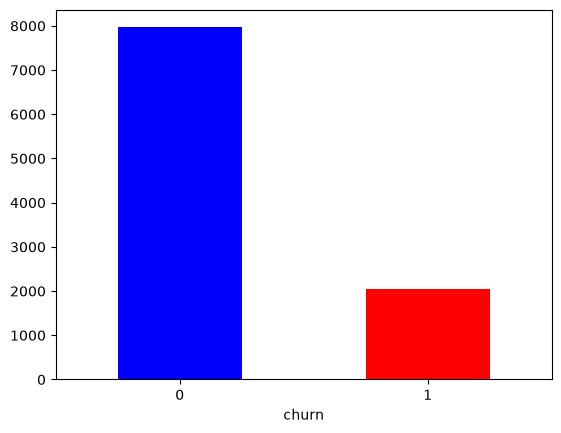

In [125]:
# Quantidade de churn
tabela["churn"].value_counts().plot(kind = "bar", color = ["blue","red"])
plt.xticks(rotation = 0)
plt.show()

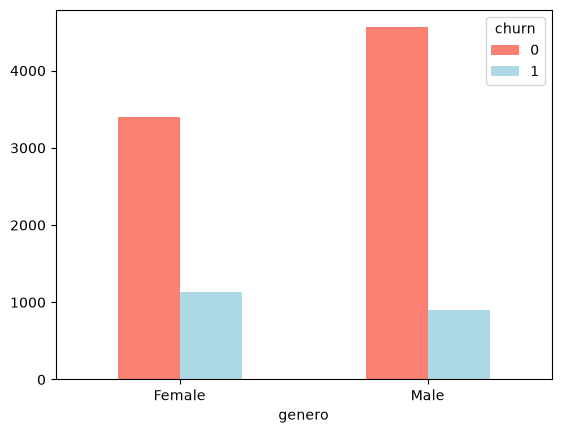

In [126]:
# relacao churn por genero
pd.crosstab(tabela["genero"], tabela["churn"]).plot(kind = "bar", color = ["salmon","lightblue"])

plt.xticks(rotation = 0)
plt.show()

Há uma tendencia maior de clientes que são mulheres daram churn

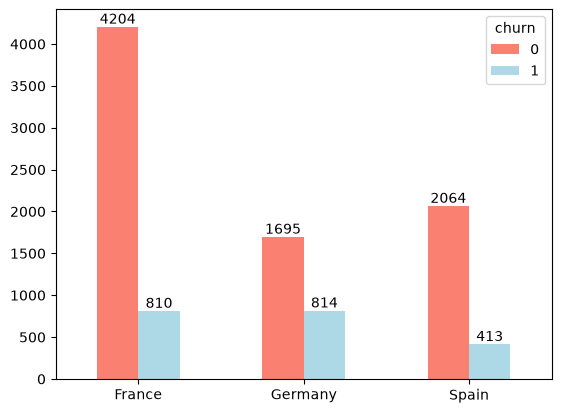

In [127]:
# Relação entre churn e cada país 
ax = pd.crosstab(tabela["pais_residencia"],tabela["churn"]).plot(kind = "bar", color = ["salmon","lightblue"])

for barra in ax.containers:
    ax.bar_label(barra)

plt.xticks(rotation = 0)
plt.xlabel("")
plt.show()

É possivel perceber que mesmo a frança possuindo mais clientes, a Alemanha acaba tendo um valor maior de churns, enquanto os valores da França e Espanha são praticamente proporcionais

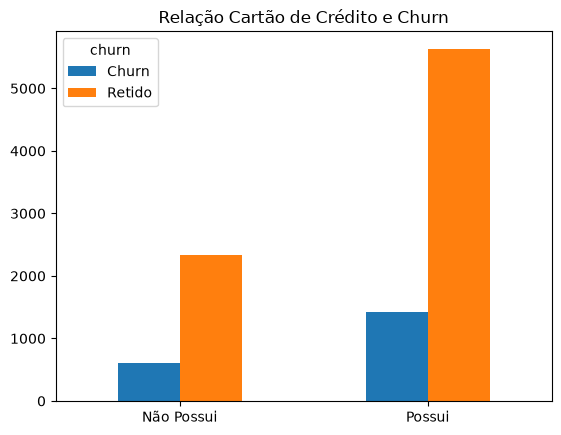

In [128]:
pd.crosstab(tabela["possui_cartao_credito"].map({0: "Não Possui",1: "Possui"})
            , tabela["churn"].map({0: "Retido", 1:"Churn"})).plot(kind = "bar")

plt.xticks(rotation = 0)
plt.xlabel("")
plt.title("Relação Cartão de Crédito e Churn")
plt.show()

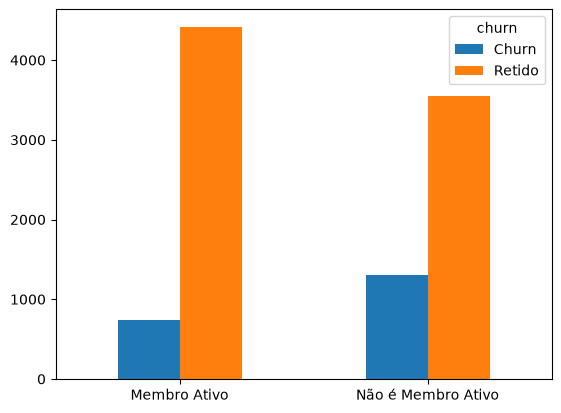

In [129]:
pd.crosstab(tabela["membro_ativo"].map({0: "Não é Membro Ativo", 1: "Membro Ativo"}),
         tabela["churn"].map({0: "Retido", 1: "Churn"})).plot(kind = "bar")

plt.xlabel("")
plt.xticks(rotation = 0)
plt.show()

A tendência é de que o churn aumente para clientes que não são ativos

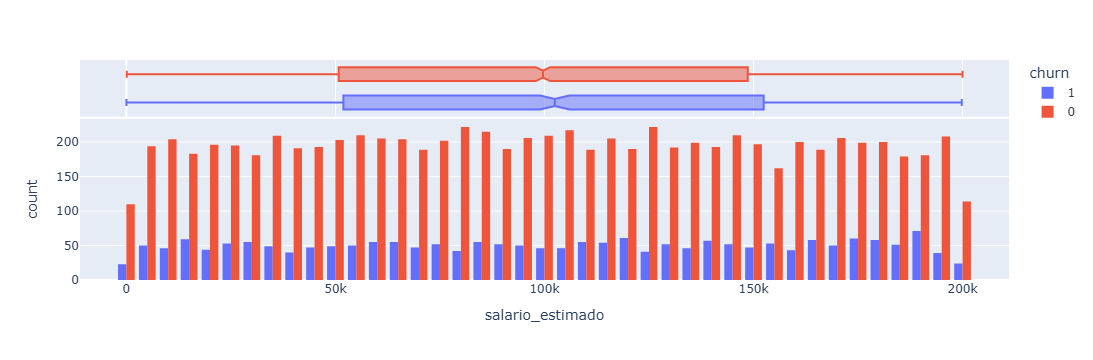

In [130]:
churn_salario = px.histogram(tabela,
                x = "salario_estimado",
                color = "churn",
                marginal = "box",
                barmode = "group")
churn_salario.show()

Podemos observar que não existe uma correlação entre o cliente ter dado churn e o valor de seu salario estimado

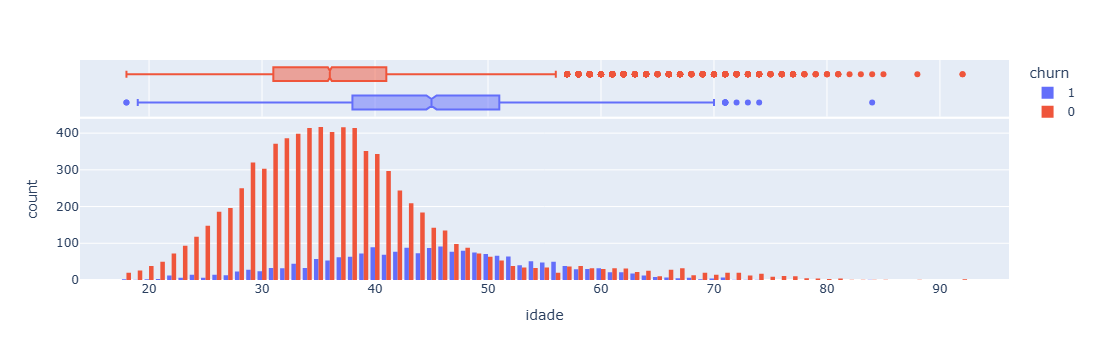

In [131]:
churn_idade = px.histogram(tabela,
                          x = "idade",
                          color = "churn",
                          marginal = "box",
                          barmode = "group")
churn_idade.show()

Analisando o Gráfico acima identificamos um ponto que chama atenção a relação ao churn. Parece crescer para clientes mais velhos, além de que a distribuição das idades dos clientes que ainda estão com o serviço é bem heterogênea, visto que há uma presença bem alta de outliers, reforçando a afirmação que a idade influencia nos churns

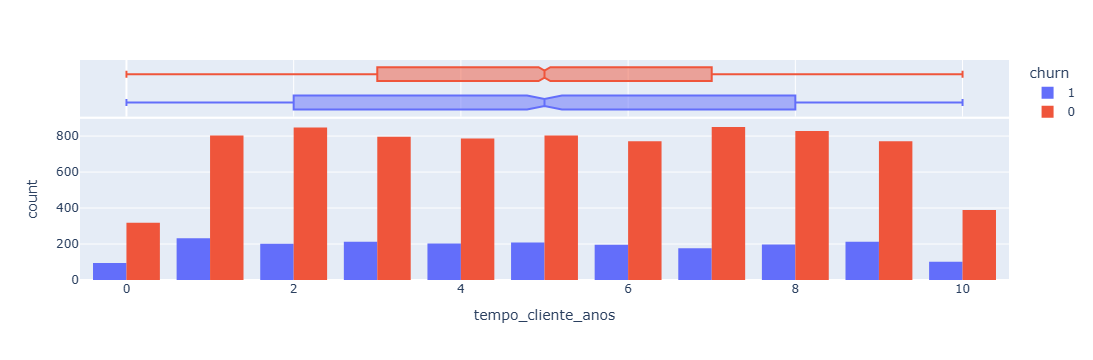

In [132]:
churn_tempo = px.histogram(tabela,
                          x = "tempo_cliente_anos",
                          color = "churn",
                          marginal = "box",
                          barmode = "group")
churn_tempo.show()

Já em relação ao tempo que o cliente possui o serviço, tal variável não parece contruibuir para a existência do churn

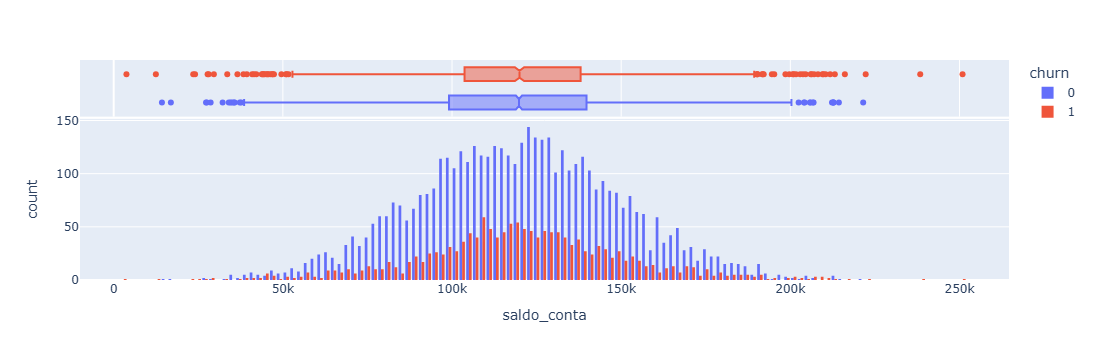

In [133]:
churn_tempo = px.histogram(tabela[tabela["saldo_conta"] != 0],
                          x = "saldo_conta",
                          color = "churn",
                          marginal = "box",
                          barmode = "group")
churn_tempo.show()

Aparentemente não existe nenhuma relação forte entre o valor de saldo na conta e a variável de churn

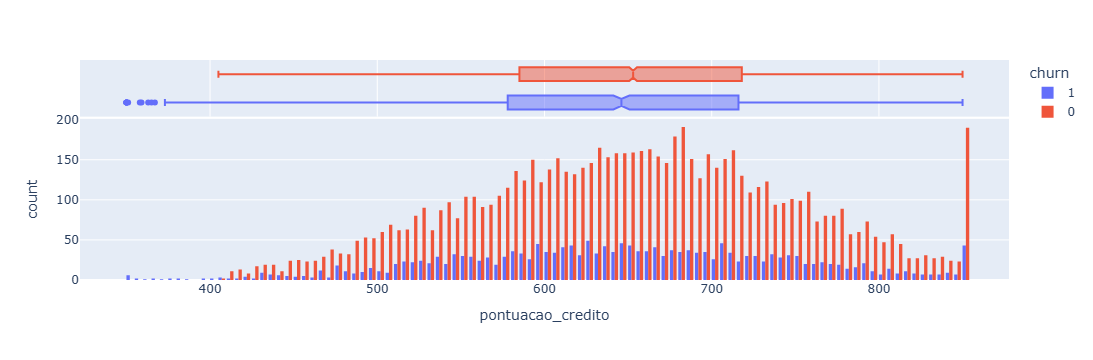

In [134]:
pontuacao_churn = px.histogram(tabela,
                              x = "pontuacao_credito",
                              color = "churn",
                              marginal = "box",
                              barmode = "group")
pontuacao_churn.show()

Olhando para o histograma encontramos uma razão maior entre churns e clientes retidos nos valores de pontuação de crédito menores de 400

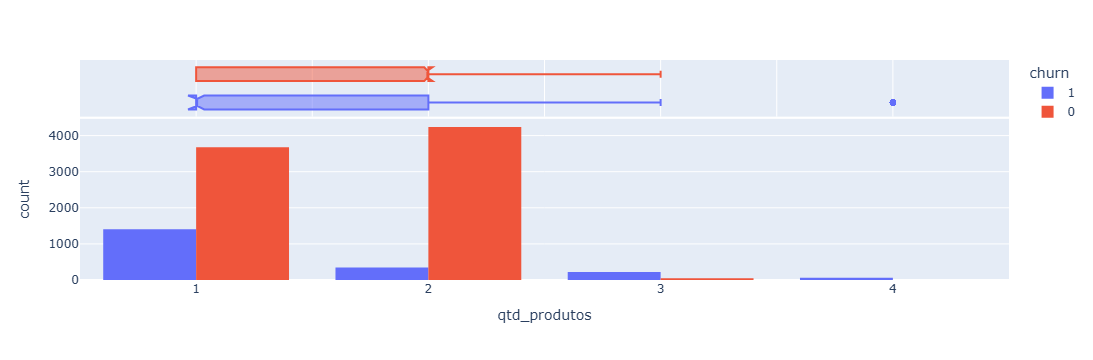

In [135]:
quantidade_produtos_churn = px.histogram(tabela,
                                        x = "qtd_produtos",
                                        color = "churn",
                                        marginal = "box",
                                        barmode = "group")

quantidade_produtos_churn.show()

A quantidade de produtos que o cliente possui tende a afetar o churn, a proporção de churn pra clientes de 1 unidade do produto acaba sendo maior do que clientes com dois produtos, já para 3 e 4 produtos, o churn passa a ser maior do que a retenção do cliente

## 5. Transformando e Criando alguns dados

In [136]:
tabela.head()

,numero_linha,id_cliente,sobrenome,pontuacao_credito,pais_residencia,genero,idade,tempo_cliente_anos,saldo_conta,qtd_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [137]:
tabela_nova = pd.get_dummies(tabela, columns = ["pais_residencia","genero"] , dtype = int)
# transformando dados que estão em forma de texto para valores numericos

In [138]:
tabela_nova.head()

,numero_linha,id_cliente,sobrenome,pontuacao_credito,idade,tempo_cliente_anos,saldo_conta,qtd_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churn,pais_residencia_France,pais_residencia_Germany,pais_residencia_Spain,genero_Female,genero_Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


In [139]:
tabela_treinamento = tabela_nova.drop(["numero_linha","id_cliente","sobrenome"], axis = 1)
# Apagando dados que não são necessários para o modelo

In [140]:
tabela_treinamento.head()

,pontuacao_credito,idade,tempo_cliente_anos,saldo_conta,qtd_produtos,possui_cartao_credito,membro_ativo,salario_estimado,churn,pais_residencia_France,pais_residencia_Germany,pais_residencia_Spain,genero_Female,genero_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,1,0


In [141]:
tabela_treinamento.dtypes

pontuacao_credito            int64
idade                        int64
tempo_cliente_anos           int64
saldo_conta                float64
qtd_produtos                 int64
possui_cartao_credito        int64
membro_ativo                 int64
salario_estimado           float64
churn                        int64
pais_residencia_France       int64
pais_residencia_Germany      int64
pais_residencia_Spain        int64
genero_Female                int64
genero_Male                  int64
dtype: object

In [142]:
# Dividindo os dados que serão utilizados no modelo
x = tabela_treinamento.drop("churn", axis = 1)
y = tabela_treinamento["churn"]

In [143]:
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(x) # Transformando todos os dados para uma mesma escala numérica

In [144]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x,y, test_size= 0.25, random_state= 42)

In [145]:
modelos = {
    "Regressão Logística (Linear)": LogisticRegression(random_state=42),
    "Random Forest (Espacial)": RandomForestClassifier(random_state=42),
    "Gradient Boosting (Otimização)": GradientBoostingClassifier(random_state=42) 
}

--- Avaliando o modelo Regressão Logística (Linear) ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.88      2003
           1       0.46      0.12      0.19       497

    accuracy                           0.80      2500
   macro avg       0.64      0.54      0.53      2500
weighted avg       0.74      0.80      0.75      2500



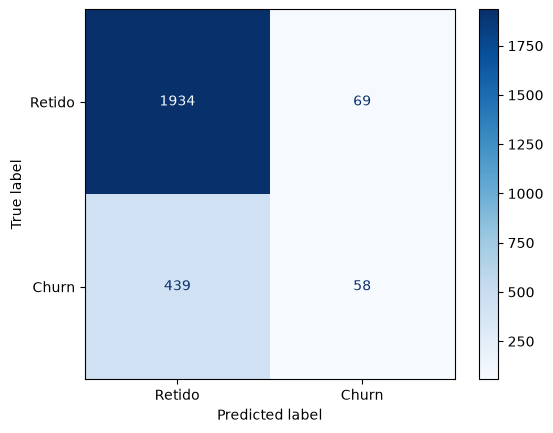

--- Avaliando o modelo Random Forest (Espacial) ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2003
           1       0.79      0.47      0.59       497

    accuracy                           0.87      2500
   macro avg       0.84      0.72      0.76      2500
weighted avg       0.86      0.87      0.86      2500



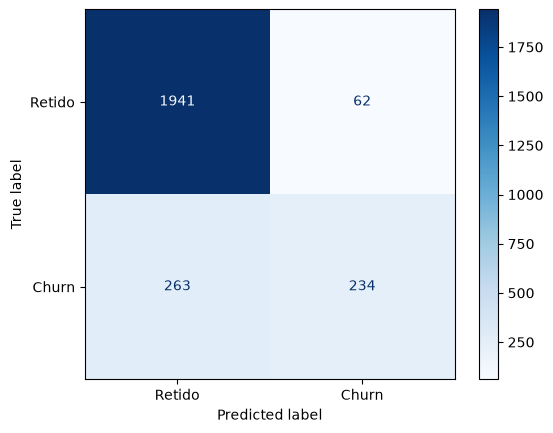

--- Avaliando o modelo Gradient Boosting (Otimização) ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2003
           1       0.79      0.49      0.60       497

    accuracy                           0.87      2500
   macro avg       0.84      0.73      0.76      2500
weighted avg       0.86      0.87      0.86      2500



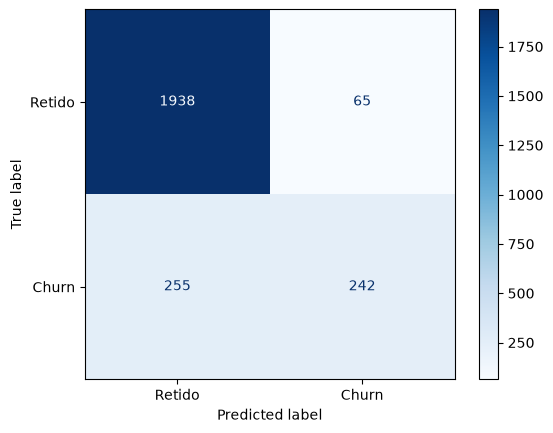

In [146]:


for nome, modelo in modelos.items():
    print(f"--- Avaliando o modelo {nome} ---")

    modelo.fit(x_treino,y_treino)

    previsoes = modelo.predict(x_teste)

    print(classification_report(y_teste, previsoes))

    ConfusionMatrixDisplay.from_predictions(y_teste, previsoes, cmap='Blues', 
                                            display_labels=['Retido', 'Churn'])
    plt.show()

Analisando os as tabelas referente a qualidade que os modelos conseguiram chegar, podemos afirmar que o resultado obtido não foi o esperado:

- O primeiro modelo (Logístico) conseguiu capturar bem os clientes que ficaram retidos e foram poucos falsos positivos, já o desempenho em relação os churns não foi satisfátorio, O F1-Score em relação a essa variável foi de 0.19, um valor muito baixo que reforça a afirmação
- O segundo modelo e terceiro modelo obtiveram resultados praticamente identicos, também captaram os clientes retidos e poucos falsos postivos para essa mesma variável, em relação aos churns seu desempenho foi mais satisfatório do que o primeiro modelo com um valor de F1-Score de 0.59 e 0.6 respectivamente

Os resultados de todos os modelos ainda não foram aceitaveis por esse motivo tentaremos encontrar medidas para impactar possitivamente os resultados

## 6. Engenharia de Recursos

Para a tentativa de melhorar os modelos, criaremos mais informações matemáticas que auxiliem os processos de machine learning

In [147]:
tabela_treinamento["racio_idade_tempo"] = tabela_treinamento["idade"] / (tabela_treinamento["tempo_cliente_anos"] + 1) # Coluna para demonstrar a relação de idade e tempo como cliente
tabela["racio_saldo_salario"] = (tabela_treinamento["saldo_conta"] / tabela_treinamento["salario_estimado"]) # Relação entre saldo na conta e salario

# Como alguns valores de salário estimado pode ser zero os valores da razão tenderão para infinito, tal situação gera um problema aos modelos

tabela["racio_saldo_salario"] = tabela["racio_saldo_salario"].replace([np.inf,-np.inf], np.nan) 
tabela["racio_saldo_salario"] = tabela["racio_saldo_salario"].fillna(0)

tabela_treinamento["faixa_etaria"] = pd.cut(tabela_treinamento["idade"], bins = [0,30,50,100], labels = ["Jovem", "Adulto", "Senhor"])
tabela_treinamento = pd.get_dummies(tabela_treinamento, columns = ["faixa_etaria"], dtype = int)



Outro fator que deve ser analisado visto que não conseguimos valores interessantes, seria conferir a correlação dos dados

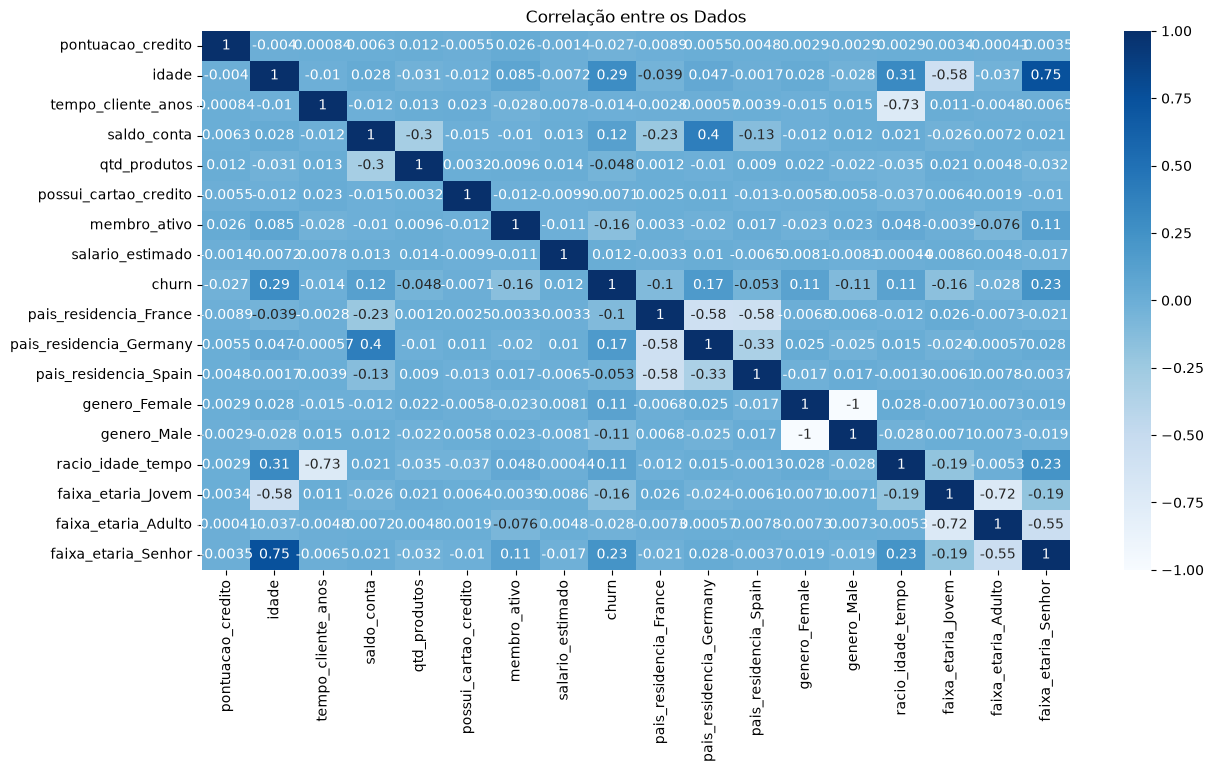

In [148]:
correlacao = tabela_treinamento.corr()
plt.figure(figsize = (14,7))
sns.heatmap(correlacao, annot = True, cmap = "Blues")
plt.title("Correlação entre os Dados")
plt.show()

Nenhum valor possui uma correlação que necessite de preocupação

## 7. Testando Novamente os Modelos

In [149]:
x = tabela_treinamento.drop("churn", axis = 1)
y = tabela_treinamento["churn"]

In [150]:
scaller = StandardScaler()
dados_normalizados = scaller.fit_transform(x)

In [151]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x,y, test_size= 0.25, random_state= 42)

Como vimos anteriormente os dados em relação a clientes retidos e churn, possuem uma proporção que não é a recomendada para a utilização dos modelos Logístico e de Random Forest, por esse motivo usaremos um parametro dentro do modelo para balencear esse pontos

In [152]:
modelos = {
   
    "Regressão Logística (Linear)": LogisticRegression(random_state=42, class_weight='balanced'),
    "Random Forest (Espacial)": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting (Otimização)": GradientBoostingClassifier(random_state=42) 
    
}

--- Analisando o modelo Regressão Logística (Linear) ---
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      2003
           1       0.34      0.67      0.45       497

    accuracy                           0.68      2500
   macro avg       0.62      0.67      0.61      2500
weighted avg       0.78      0.68      0.71      2500



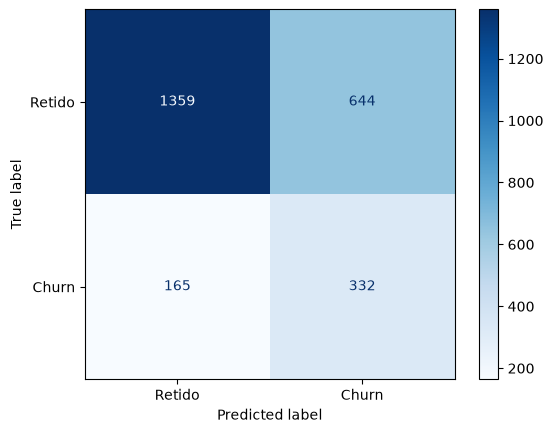

--- Analisando o modelo Random Forest (Espacial) ---
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      2003
           1       0.62      0.59      0.61       497

    accuracy                           0.85      2500
   macro avg       0.76      0.75      0.76      2500
weighted avg       0.84      0.85      0.85      2500



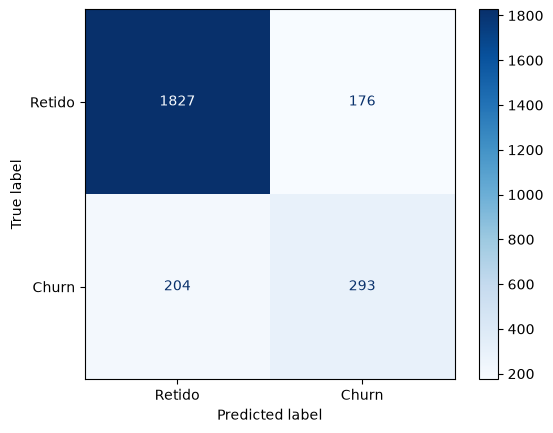

--- Analisando o modelo Gradient Boosting (Otimização) ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2003
           1       0.77      0.48      0.60       497

    accuracy                           0.87      2500
   macro avg       0.83      0.72      0.76      2500
weighted avg       0.86      0.87      0.86      2500



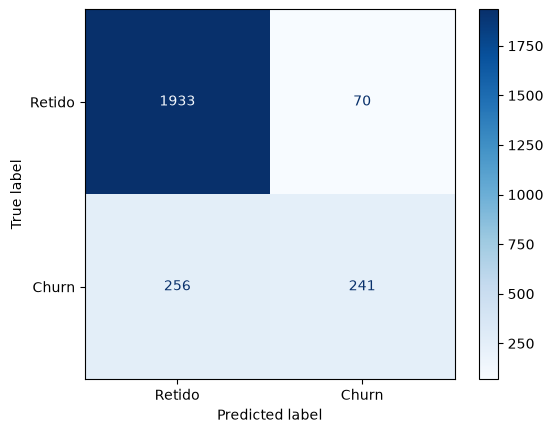

In [153]:
for nome, modelo in modelos.items():
    print(f"--- Analisando o modelo {nome} ---")
    
    modelo.fit(x_treino,y_treino)

    previsoes = modelo.predict(x_teste)

    print(classification_report(y_teste,previsoes))

    ConfusionMatrixDisplay.from_predictions(y_teste, previsoes, cmap='Blues', 
                                            display_labels=['Retido', 'Churn'])
    plt.show()

Com a utilização dos métodos para auxiliar os modelos conseguimos resultados mais interessantes principalmente para o modelo Random Forest. Tal modelo será justamente o escolhido para o projeto

Como já escolhemos o modelo, testaremos alguns hiperparametros para usarmos a sua melhor configuração 

In [154]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}
modelo = RandomForestClassifier(random_state=42)


grid_search = estimator = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    scoring='f1', # usando como parametro o valor de F1-Score, visto que ele foi o problema anteriormente
    cv=3,         
    n_jobs=-1     
)


grid_search.fit(x_treino, y_treino)


print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)


melhor_modelo = grid_search.best_estimator_

Melhores parâmetros encontrados:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}


In [155]:
previsoes_melhor_modelo = melhor_modelo.predict(x_teste)

In [156]:
print(classification_report(y_teste, previsoes_melhor_modelo))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      2003
           1       0.55      0.71      0.62       497

    accuracy                           0.83      2500
   macro avg       0.74      0.78      0.75      2500
weighted avg       0.85      0.83      0.83      2500



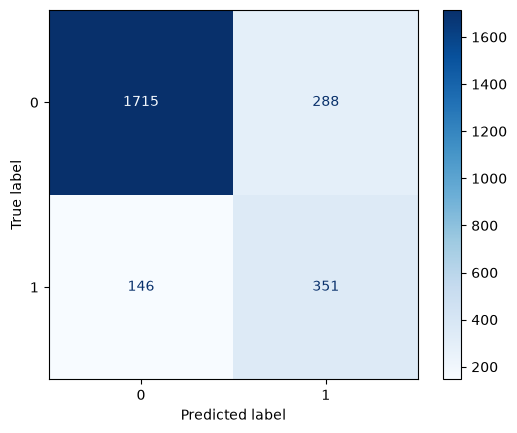

In [157]:
ConfusionMatrixDisplay.from_predictions(y_teste, previsoes_melhor_modelo, cmap = "Blues")

In [158]:
importancia = melhor_modelo.feature_importances_
nomes_importancia = x_teste.columns

tabela_importancia = pd.DataFrame({"Variavel": nomes_importancia, "Valores": importancia}).sort_values("Valores", ascending = True)

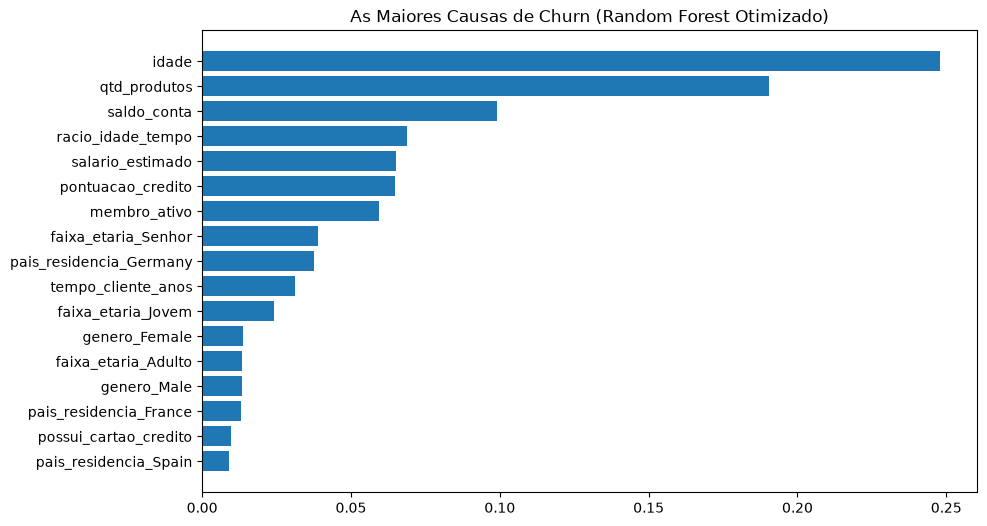

In [159]:
plt.figure(figsize = (10,6))
plt.barh(tabela_importancia["Variavel"],tabela_importancia["Valores"])
plt.title("As Maiores Causas de Churn (Random Forest Otimizado)")
plt.show()

Observando o gráfico em relação a como o modelo classificou a importância das variáveis em relação ao churn temos, idade, quantidade de produtos e saldo na conta como principais motivos

## 8. Conclusão e Próximos Passos

Após testar diferentes modelos (Regressão Logística, Random Forest, Gradient Boost), realizar engenharia de recursos com variáveis de negócios e realizar teste com hiperparemetros concluimos que o melhor modelo para esse caso seria o Random Forest visando prever os churns

**Principais Valorizações para o Negócio:**
- O modelo reduziu drasticamente os alarmes falsos (Falsos Positivos), protegendo o orçamento de campanhas de retenção da empresa.
- A identificação precoce permite que a instituição financeira aja de forma preventiva, oferecendo benefícios ou suporte direcionado aos clientes com maior probabilidade de cancelamento.

